In [1]:
# 1.导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['Heiti TC']



In [2]:
# 2.导入数据
df = pd.read_csv('data/house_sales.csv')

In [3]:
# 3.数据概览
print('总记录数：',len(df))
print('字段数量：',len(df.columns))
df.head()
# df.info()

总记录数： 106118
字段数量： 12


,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm


In [4]:
# 4.数据清洗
# df.drop(columns='origin_url', inplace=True)
# df.head()
# 检查是否有缺失值
df.isna().sum()
df.dropna(inplace=True)
print(len(df))

57520


In [5]:
# 检查是否有重复的数据
df.duplicated().sum()
# 删除重复数据
df.drop_duplicates(inplace=True)
print(len(df))

28379


In [6]:
df.head()
df['area'] = df['area'].str.replace('㎡','').astype(float)

In [7]:
# price转换
df['price'] = df['price'].str.replace('万','').astype(float)

In [8]:
df.head()
# 朝向的数据类型转换
df['toward'] = df['toward'].astype('category')
df.info()


<class 'pandas.DataFrame'>
Index: 28379 entries, 0 to 106088
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   city        28379 non-null  str     
 1   address     28379 non-null  str     
 2   area        28379 non-null  float64 
 3   floor       28379 non-null  str     
 4   name        28379 non-null  str     
 5   price       28379 non-null  float64 
 6   province    28379 non-null  str     
 7   rooms       28379 non-null  str     
 8   toward      28379 non-null  category
 9   unit        28379 non-null  str     
 10  year        28379 non-null  str     
 11  origin_url  28379 non-null  str     
dtypes: category(1), float64(2), str(9)
memory usage: 2.6 MB


In [9]:
# 单价的数据类型转换
df.head()
df['unit'] = df['unit'].str.replace('元/㎡','').astype(float)
df.info()


<class 'pandas.DataFrame'>
Index: 28379 entries, 0 to 106088
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   city        28379 non-null  str     
 1   address     28379 non-null  str     
 2   area        28379 non-null  float64 
 3   floor       28379 non-null  str     
 4   name        28379 non-null  str     
 5   price       28379 non-null  float64 
 6   province    28379 non-null  str     
 7   rooms       28379 non-null  str     
 8   toward      28379 non-null  category
 9   unit        28379 non-null  float64 
 10  year        28379 non-null  str     
 11  origin_url  28379 non-null  str     
dtypes: category(1), float64(3), str(8)
memory usage: 2.6 MB


In [10]:
df.head()
df['year'] = df['year'].str.replace('年建','').astype(int)
df.info()

<class 'pandas.DataFrame'>
Index: 28379 entries, 0 to 106088
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   city        28379 non-null  str     
 1   address     28379 non-null  str     
 2   area        28379 non-null  float64 
 3   floor       28379 non-null  str     
 4   name        28379 non-null  str     
 5   price       28379 non-null  float64 
 6   province    28379 non-null  str     
 7   rooms       28379 non-null  str     
 8   toward      28379 non-null  category
 9   unit        28379 non-null  float64 
 10  year        28379 non-null  int64   
 11  origin_url  28379 non-null  str     
dtypes: category(1), float64(3), int64(1), str(7)
memory usage: 2.6 MB


In [11]:
# 异常值的处理
# 房屋面积的异常处理
# df[df['area']<20]
# df[df['area']>600]
# df = df[(df['area']>20) &  (df['area']<600) ]

In [12]:
df

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.00,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.00,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.00,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.00,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.00,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,https://hf.esf.fang.com/chushou/3_381138154.htm
...,...,...,...,...,...,...,...,...,...,...,...,...
106080,广元,万达广场-雪峰,61.11,中层（共6层）,富康小区,37.0,四川,2室2厅,南北向,6055.0,2012,https://guangyuan.esf.fang.com/chushou/3_17403...
106082,广元,万达广场-广元市万源新区万源二街(南河4号桥直行100,89.94,中层（共26层）,南郡,73.0,四川,2室2厅,南向,8117.0,2016,https://guangyuan.esf.fang.com/chushou/3_17329...
106084,广元,万达广场-广元市万源新区万源二街(南河4号桥直行100,85.00,高层（共25层）,南郡,75.0,四川,2室1厅,南向,8824.0,2016,https://guangyuan.esf.fang.com/chushou/3_17112...
106086,广元,利州广场-广元市利州区兴安路519号,85.00,低层（共18层）,御景湾,86.0,四川,2室2厅,西南向,10118.0,2015,https://guangyuan.esf.fang.com/chushou/3_17459...


In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 28379 entries, 0 to 106088
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   city        28379 non-null  str     
 1   address     28379 non-null  str     
 2   area        28379 non-null  float64 
 3   floor       28379 non-null  str     
 4   name        28379 non-null  str     
 5   price       28379 non-null  float64 
 6   province    28379 non-null  str     
 7   rooms       28379 non-null  str     
 8   toward      28379 non-null  category
 9   unit        28379 non-null  float64 
 10  year        28379 non-null  int64   
 11  origin_url  28379 non-null  str     
dtypes: category(1), float64(3), int64(1), str(7)
memory usage: 2.6 MB


In [14]:
# 房屋售价的异常处理 IQR
Q1 = df['price'].quantile(0.25) # 分位数
Q3 = df['price'].quantile(0.75) # 分位数
IQR = Q3 - Q1
# 上边缘，下边缘
low_price = Q1 - 1.5 * IQR
high_price = Q3 + 1.5 * IQR
# 使用布尔索引 判断异常数据
df[(df['price']>high_price) & (df['price']<low_price)]
# 查询正常数据
len(df[(df['price']<high_price) & (df['price']>low_price)])

df = df[(df['price']<high_price) & (df['price']>low_price)]


In [15]:
df.head()


,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,https://hf.esf.fang.com/chushou/3_381138154.htm


In [16]:
# 5.新的特征数据构造
# 地区district
df['district'] = df['address'].str.split('-').str[0]
# 楼层的类型floor_type
# 转换类型
df['floor_type'] = df['floor'].str.split('（').str[0].astype('category')



# 6.问题分析以及可视化


In [17]:
# 随机取样查看数据
df.sample(10)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,district,floor_type
64158,东台,亭湖-黄海路与文港路交汇处(文港路东侧),100.00,中层（共24层）,万泰时代城,127.0,江苏,3室2厅,南向,12700.0,2014,https://yancheng.esf.fang.com/chushou/3_176052...,亭湖,中层
68338,耒阳,解放西路-蒸湘-解放西路-岳屏小区,139.00,中层（共8层）,岳屏小区,50.8,湖南,3室2厅,南北向,3655.0,2008,https://hengyang.esf.fang.com/chushou/3_174578...,解放西路,中层
20850,元氏,西里-长丰路4号(民心河长丰路交口东南角),142.63,中层（共6层）,长丰苑,245.0,河北,3室2厅,南北向,17177.0,2000,https://sjz.esf.fang.com/chushou/3_172816991.htm,西里,中层
44088,桂林,北极广场-站前路29号,107.00,高层（共17层）,联发乾景,90.0,广西,3室2厅,南北向,8411.0,2015,https://guilin.esf.fang.com/chushou/3_40226094...,北极广场,高层
68278,耒阳,华新开发区-蒸湘高新开发区华新大道56号(市一中斜对面),108.00,高层（共32层）,棕榈园,84.0,湖南,3室2厅,南向,7778.0,2013,https://hengyang.esf.fang.com/chushou/3_176009...,华新开发区,高层
29730,德惠,劳动公园-万科蓝山长春市二道区东盛大街666号,92.60,中层（共28层）,万科蓝山,125.0,吉林,2室2厅,南北向,13499.0,2014,https://changchun.esf.fang.com/chushou/3_27490...,劳动公园,中层
7118,句容,仙林宝华镇-句容市 仙林大道与汤龙路交汇处东南角,99.00,中层（共18层）,仙林东郡,100.0,江苏,3室2厅,南向,10101.0,2015,https://jr.esf.fang.com/chushou/3_154261482.htm,仙林宝华镇,中层
15744,中山,坦洲镇-十四村界狮南路(界狮南路尽头),102.40,中层（共18层）,中澳世纪城,150.0,广东,3室2厅,东南向,14648.0,2010,https://zs.esf.fang.com/chushou/3_396573541.htm,坦洲镇,中层
47442,户县,电子城-太白南路与丈八东路十字向东500米,103.13,中层（共33层）,裕昌太阳城,160.0,陕西,2室2厅,南北向,15514.0,2012,https://xian.esf.fang.com/chushou/3_168792245.htm,电子城,中层
22286,丰县,东苑-民富园路与德政路交叉处(65路终点站向东10,135.00,中层（共6层）,东方美地,170.0,江苏,3室2厅,南北向,12593.0,2012,https://xz.esf.fang.com/chushou/3_377253631.htm,东苑,中层


In [18]:
# 使用函数的方式
def fun1(str1):
    print(str1)
    # 处理
    if pd.isnull(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    else: return '未知'

df['floor_type2'] = df['floor'].apply(fun1).astype('category')


中层（共18层）
中层（共18层）
中层（共22层）
高层（共30层）
中层（共27层）
低层（共26层）
低层（共8层）
中层（共28层）
低层（共6层）
低层（共28层）
中层（共15层）
高层（共26层）
低层（共32层）
中层（共12层）
高层（共32层）
低层（共31层）
高层（共19层）
高层（共22层）
中层（共18层）
中层（共18层）
中层（共33层）
高层（共7层）
中层（共9层）
中层（共26层）
中层（共24层）
低层（共33层）
中层（共14层）
低层（共18层）
中层（共33层）
高层（共27层）
高层（共18层）
中层（共6层）
中层（共13层）
高层（共19层）
高层（共11层）
高层（共23层）
高层（共12层）
低层（共17层）
高层（共22层）
低层（共30层）
中层（共27层）
中层（共11层）
中层（共28层）
中层（共6层）
高层（共8层）
低层（共7层）
中层（共18层）
高层（共19层）
中层（共26层）
高层（共6层）
高层（共17层）
中层（共18层）
高层（共17层）
高层（共18层）
低层（共17层）
中层（共18层）
中层（共24层）
高层（共35层）
高层（共18层）
高层（共6层）
中层（共33层）
低层（共6层）
中层（共8层）
高层（共33层）
中层（共7层）
中层（共18层）
低层（共6层）
中层（共32层）
高层（共18层）
低层（共16层）
中层（共29层）
中层（共11层）
中层（共20层）
高层（共16层）
中层（共8层）
中层（共15层）
中层（共6层）
中层（共6层）
低层（共6层）
中层（共11层）
高层（共28层）
低层（共25层）
低层（共27层）
中层（共33层）
中层（共31层）
中层（共31层）
低层（共32层）
中层（共32层）
高层（共18层）
低层（共11层）
中层（共33层）
低层（共34层）
中层（共12层）
中层（共19层）
高层（共11层）
中层（共16层）
低层（共18层）
中层（共20层）
中层（共16层）
中层（共28层）
中层（共20层）
高层（共7层）
中层（共33层）
中层（共31层）
低层（共17层）
中层（共29层）
中层（共6层）
中层（共13层）
中层（共6层）
高层（共17层）
高层（共34层）
中层（共7层）
中层（共16层）
中层（共1

In [19]:
df.sample(10)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,district,floor_type,floor_type2
57896,阳曲,"学府街-学府街128号,学府街与滨河东路交汇处往东3",104.79,高层（共17层）,碧水兰亭,137.0,山西,3室2厅,东北向,13074.0,2013,https://taiyuan.esf.fang.com/chushou/3_2686088...,学府街,高层,高楼层
84352,周至,明德门-东仪路22号,95.60,高层（共26层）,唐园假日新城,120.0,陕西,2室2厅,南向,12552.0,2008,https://xian.esf.fang.com/chushou/3_168538503.htm,明德门,高层,高楼层
10060,日照,东港-海曲路与日照路交汇处,37.00,中层（共28层）,赛福特影视广场,30.0,山东,1室1厅,北向,8108.0,2020,https://rz.esf.fang.com/chushou/3_166556990.htm,东港,中层,中楼层
22060,榆树,南湖南-南湖大路与南湖新村中街交汇处,88.00,中层（共6层）,南湖新村,240.0,吉林,2室1厅,南北向,27273.0,2000,https://changchun.esf.fang.com/chushou/3_27461...,南湖南,中层,中楼层
85986,沧州,火车站-解放东路与千童南大道交汇处北行400米,90.00,中层（共19层）,榕城世家,105.0,河北,2室2厅,南向,11667.0,2013,https://cangzhou.esf.fang.com/chushou/3_165618...,火车站,中层,中楼层
6378,济南,郭店-工业南路与飞跃大道交汇处向东1500米,101.00,低层（共30层）,旭辉银盛泰星瀚城,115.0,山东,3室2厅,西南向,11386.0,2020,https://jn.esf.fang.com/chushou/3_180641632.htm,郭店,低层,低楼层
6142,吉林,中东新生活-望云街于和平路交会,95.00,低层（共31层）,神华万利城,59.0,吉林,3室2厅,南北向,6211.0,2014,https://jl.esf.fang.com/chushou/3_271254770.htm,中东新生活,低层,低楼层
7174,句容,南京周边-句容,109.00,中层（共26层）,泰禾金尊府项目,128.0,江苏,3室2厅,南向,11743.0,2020,https://jr.esf.fang.com/chushou/3_154241461.htm,南京周边,中层,中楼层
20066,元氏,新华路南-新华路296-1号(新华路与水产西街街交口西,148.00,低层（共18层）,盛安嘉园,285.0,河北,3室2厅,南北向,19257.0,2009,https://sjz.esf.fang.com/chushou/3_173430661.htm,新华路南,低层,低楼层
62406,滁州,南谯区-滁州市花园路与凤阳路交口东北侧,108.00,中层（共21层）,凯迪融创·玉兰公馆,91.8,安徽,3室2厅,南向,8500.0,2017,https://chuzhou.esf.fang.com/chushou/3_1746174...,南谯区,中层,中楼层


In [20]:
# 是否是直辖市zxs
# def fun2(str2):
#     if str2 in ['北京','上海','天津','重庆']:
#         return True
#     else:
#         return False
# 简化
def fun2(str2):
   return True  if str2 in ['北京','上海','天津','重庆'] else  False

# df['city'].apply(fun2)
# 使用lambda表达式
df['zxs'] = df['city'].apply(lambda  x: fun2(x))


In [21]:
# 卧室的数量
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype('int')


In [22]:
# 客厅的数量livingrooms
# df['livingrooms'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype('int')
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype('int')


In [23]:
# 楼龄building_age
df['building_age'] = 2025 - df['year']

In [29]:
# 价格的分段price_labels
# df.sample(10)
df['price_labels'] = pd.cut(df['price'],bins=4,labels=['低价','中价','高价','豪华'])

In [30]:
df.sample(10)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,district,floor_type,floor_type2,zxs,bedrooms,livingrooms,building_age,price_labels
105914,连江,江滨东大道-阳光城山与海快安区儒江东路(江滨东大道船舶大,72.7,中层（共28层）,阳光城山与海,125.0,福建,3室2厅,南北向,17194.0,2017,https://fz.esf.fang.com/chushou/3_165996764.htm,江滨东大道,中层,中楼层,False,3,2,8,中价
38316,石家庄,天山海世界-长江大道1号润丰盛世家园,91.3,高层（共18层）,心海假日,140.0,河北,2室2厅,南北向,15334.0,2010,https://sjz.esf.fang.com/chushou/3_173126515.htm,天山海世界,高层,高楼层,False,2,2,15,中价
85972,沧州,千童公园-九河东路与千童南大道交汇处北行200米,84.0,高层（共22层）,御宇国际城,81.0,河北,2室2厅,南北向,9643.0,2018,https://cangzhou.esf.fang.com/chushou/3_165199...,千童公园,高层,高楼层,False,2,2,7,低价
9272,青岛,高新区-祥茂河湿地公园东侧,89.6,高层（共31层）,世茂公园美地,126.0,山东,2室2厅,南向,14062.0,2016,https://qd.esf.fang.com/chushou/3_251182793.htm,高新区,高层,高楼层,False,2,2,9,中价
13842,宜昌,火车东站-伍家岗桔城路9号,132.0,中层（共32层）,香山福久源,113.0,湖北,3室2厅,南北向,8561.0,2016,https://yc.esf.fang.com/chushou/3_379753970.htm,火车东站,中层,中楼层,False,3,2,9,中价
71510,柳州,三中路-晨华路9号,32.0,中层（共26层）,彩虹城,52.0,广西,1室1厅,南向,16250.0,2015,https://liuzhou.esf.fang.com/chushou/3_1755430...,三中路,中层,中楼层,False,1,1,10,低价
63118,滁州,"滁州-创业大道,近海螺大道",85.0,高层（共6层）,丰乐园安置房小区,22.0,安徽,3室3厅,南北向,2588.0,2014,https://chuzhou.esf.fang.com/chushou/3_1757342...,滁州,高层,高楼层,False,3,3,11,低价
60178,保山,腾冲县-火山路与北二环十字路口,50.0,中层（共11层）,"金鹰东湖墅,欢乐湖国际度假村",35.0,云南,1室1厅,南北向,7000.0,2019,https://baoshan.esf.fang.com/chushou/3_1536577...,腾冲县,中层,中楼层,False,1,1,6,低价
98074,咸阳,人民西路-人民中路42号(开元商城正对面),99.0,中层（共18层）,咸阳中央领域,96.0,陕西,3室2厅,南北向,9697.0,2014,https://xianyang.esf.fang.com/chushou/3_388559...,人民西路,中层,中楼层,False,3,2,11,中价
16036,淄博,植物园-世纪路与昌国路路口南500米路西(植物园南1,61.0,高层（共18层）,盛世康城三期怡园,53.0,山东,2室1厅,南北向,8689.0,2014,https://zb.esf.fang.com/chushou/3_166331231.htm,植物园,高层,高楼层,False,2,1,11,低价


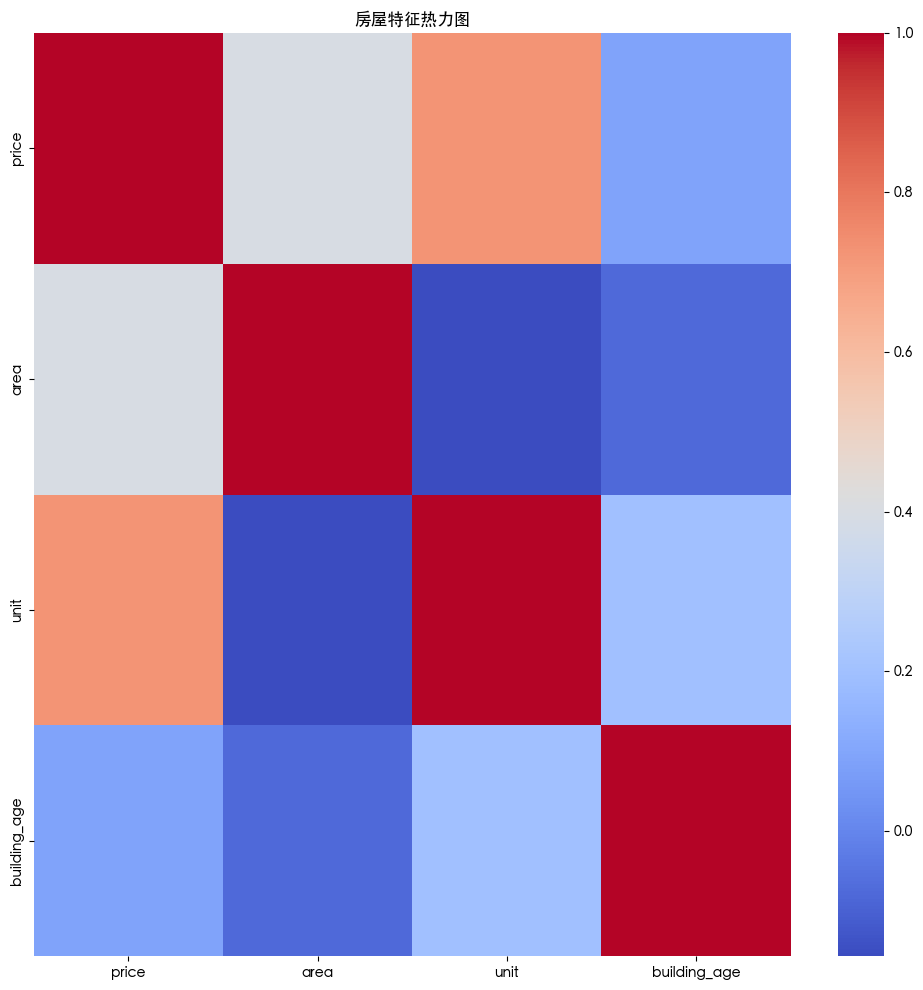

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# 6.问题分析以及可视化
'''
问题编号：A1
问题：哪些变量最影响房价？面积、楼层、房间数哪个影响更大？
分析主题：特征相关性
分析目标：了解房屋各特征对房价的线性影响
分组字段：无
指标/方法：皮尔逊相关系数
'''
# 选择数值型特征
# df.head()
a = df[['price','area','unit','building_age']].corr() # 相关系数
# 对房价的影响最大的几个因素的排序
a['price'].sort_values(ascending=False)[1:]
# 相关性的热力图
plt.figure(figsize=(10,10))
sns.heatmap(a,cmap='coolwarm') # 相关性是从上到下依次递减的
plt.title('房屋特征热力图')
plt.tight_layout()

In [44]:
'''
问题编号：A2

问题：全国房价总体分布是怎样的？是否存在极端值？
分析主题：描述性统计
分析目标：概览数值型字段的分布特征
分组字段：无
指标/方法：平均数/中位数/四分位数/标准差
'''
df.describe()


,area,price,unit,year,bedrooms,livingrooms,building_age
count,26389.000000,26389.000000,26389.000000,26389.000000,26389.000000,26389.000000,26389.000000
mean,103.926619,116.732704,11580.140096,2013.092955,2.712949,1.848194,11.907045
std,39.174129,60.568712,5867.377397,6.014015,0.801663,0.407685,6.014015
min,10.000000,9.000000,507.000000,1976.000000,0.000000,0.000000,2.000000
25%,85.000000,71.660000,7570.000000,2011.000000,2.000000,2.000000,8.000000
50%,100.000000,102.800000,10294.000000,2015.000000,3.000000,2.000000,10.000000
75%,123.000000,150.000000,14144.000000,2017.000000,3.000000,2.000000,14.000000
max,2020.000000,303.000000,132000.000000,2023.000000,9.000000,12.000000,49.000000


(array([ 997., 4612., 6623., 4848., 3356., 2261., 1297., 1094.,  717.,
         584.]),
 array([  9. ,  38.4,  67.8,  97.2, 126.6, 156. , 185.4, 214.8, 244.2,
        273.6, 303. ]),
 <BarContainer object of 10 artists>)

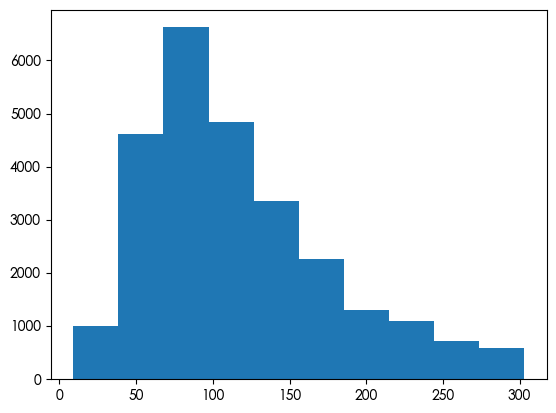

In [45]:
# 房价分布直方图
plt.subplot(111)
# 划分10个区间
plt.hist(df['price'],bins=10)

<Axes: xlabel='price', ylabel='Count'>

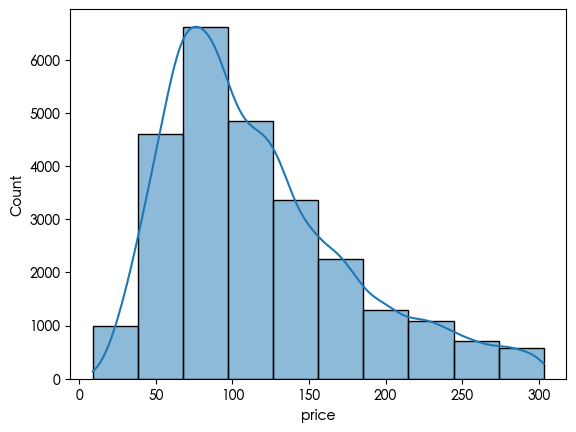

In [47]:
# 使用seaborn来实现
sns.histplot(df,x='price',bins=10,kde=True)

In [50]:
'''
问题编号：A6

问题：南北向是否真正比单一朝向贵？贵多少？
分析主题：朝向溢价
分析目标：评估不同朝向的价格差异
分组字段：towards
指标/方法：方差分析/多重比较
'''
df['toward'].value_counts()
df.groupby('toward').agg({
    'price':['median','mean'],
    'unit':'median',
    'building_age':'mean',
})

price                 unit building_age
       median        mean   median         mean
toward                                         
东北向     100.0  114.555333  12198.0    12.609524
东南向     105.0  114.531725  10860.5    10.926078
东向       94.5  109.709528  11421.0    12.787736
东西向      82.0   97.988387   8936.0    15.419355
北向       75.5   92.527907  11698.0    13.108527
南北向     103.8  118.995327  10000.0    12.059682
南向      102.0  114.178036  10727.5    11.520426
西北向     105.0  117.182782  12290.0    13.315789
西南向     138.0  139.292188  13333.0    13.414062
西向       85.0  100.948012  12500.0    13.360248

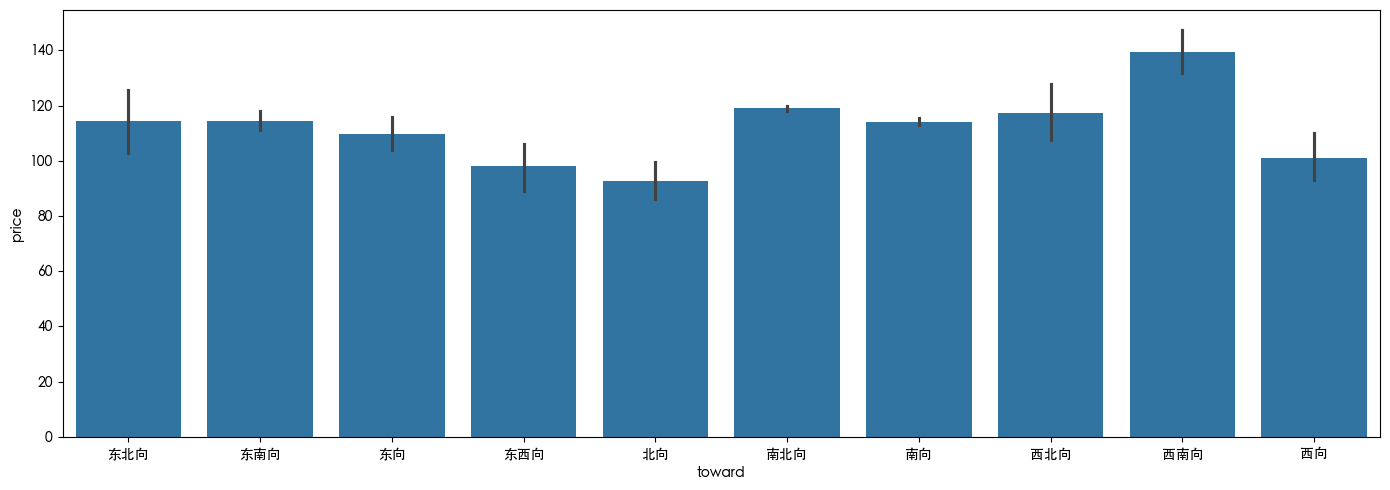

In [54]:
# 数据可视化
plt.figure(figsize=(14,5))
sns.barplot(x='toward',y='price',data=df)
plt.tight_layout()